
# GVH Diagonal Cubic 0.2.26.1 — Optimized Realistic EOS and Stellar Stability Sequences
## Équations d’état, séquences masse–rayon, causalité et stabilité des étoiles compactes

**Auteur : Charlemagne O Laurince**

---

## Objectif

Le notebook 0.2.25 a introduit la rétroaction métrique du mode directionnel radial dans les équations TOV modifiées.

Cette version construit des séquences stellaires complètes en faisant varier l’état central :

\[
\rho_c
\quad\text{ou}\quad
p_c.
\]

Les objectifs sont :

1. définir plusieurs équations d’état analytiques ;
2. fournir une interface pour des tables EOS ;
3. résoudre les séquences GR et GVH ;
4. calculer les relations masse–rayon ;
5. identifier les maxima de masse ;
6. appliquer le critère
   \[
   \frac{dM}{d\rho_c}>0;
   \]
7. calculer la masse baryonique et l’énergie de liaison ;
8. vérifier la causalité
   \[
   0\le c_s^2=\frac{dp}{d\epsilon}\le1;
   \]
9. comparer les branches stables et instables ;
10. produire des exports prêts pour une future confrontation observationnelle.

---

## Portée scientifique

Les EOS analytiques incluses sont des **prototypes de familles physiques**, pas des reproductions certifiées de tables nucléaires publiées.

Le notebook comprend une classe `TabulatedEOS` permettant de charger ultérieurement de vraies tables contenant au minimum :

\[
\epsilon,\quad p,\quad n_B.
\]

Les conclusions observationnelles devront être faites seulement après insertion et vérification de données EOS réelles.


---

## Optimisation 0.2.26.1

Cette version ajoute deux modes :

- `FAST` : vérification rapide de l’ensemble du pipeline ;
- `PRODUCTION` : grille complète, sauvegarde progressive et reprise automatique.

Optimisations principales :

1. intégration **sans `t_eval`** pendant la méthode de tir ;
2. continuation en pression centrale : la solution précédente fournit le prochain \(d_c\) ;
3. recherche locale du zéro avant une recherche globale ;
4. cache des résidus de tir ;
5. sauvegarde CSV après chaque étoile ;
6. reprise automatique après interruption ;
7. construction sûre des colonnes dépendantes afin d’éviter les `KeyError`.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.interpolate import PchipInterpolator
from scipy.optimize import root_scalar

np.set_printoptions(precision=12, suppress=True)

print("Environnement chargé.")


Environnement chargé.



# Configuration d’exécution

Choisir :

```python
RUN_MODE = "FAST"
```

pour vérifier le notebook rapidement, puis :

```python
RUN_MODE = "PRODUCTION"
```

pour la séquence complète.

Le calcul repose principalement sur SciPy/CPU. Un GPU Colab n’apporte généralement pas d’accélération à `solve_ivp`.


In [2]:

from dataclasses import dataclass
from pathlib import Path
import time

RUN_MODE = "FAST"  # "FAST" ou "PRODUCTION"

@dataclass(frozen=True)
class RunConfig:
    eos_count: int
    pressure_count: int
    rmax: float
    n_eval: int
    max_step: float
    rtol: float
    atol: float
    shooting_global_trials: int
    shooting_local_half_width: float
    checkpoint_every: int

CONFIGS = {
    "FAST": RunConfig(
        eos_count=2,
        pressure_count=8,
        rmax=22.0,
        n_eval=1800,
        max_step=0.08,
        rtol=2e-7,
        atol=2e-9,
        shooting_global_trials=13,
        shooting_local_half_width=0.04,
        checkpoint_every=1,
    ),
    "PRODUCTION": RunConfig(
        eos_count=4,
        pressure_count=28,
        rmax=40.0,
        n_eval=6000,
        max_step=0.04,
        rtol=2e-8,
        atol=1e-10,
        shooting_global_trials=25,
        shooting_local_half_width=0.025,
        checkpoint_every=1,
    ),
}

if RUN_MODE not in CONFIGS:
    raise ValueError("RUN_MODE doit être 'FAST' ou 'PRODUCTION'.")

CFG = CONFIGS[RUN_MODE]
CHECKPOINT_PATH = Path(
    f"GVH_Diagonal_Cubic_0.2.26.1_{RUN_MODE}_checkpoint.csv"
)

print("Mode :", RUN_MODE)
print(CFG)


Mode : FAST
RunConfig(eos_count=2, pressure_count=8, rmax=22.0, n_eval=1800, max_step=0.08, rtol=2e-07, atol=2e-09, shooting_global_trials=13, shooting_local_half_width=0.04, checkpoint_every=1)



# 1. Interface générale d’une EOS

Chaque EOS doit fournir :

\[
p(\epsilon),
\qquad
\epsilon(p),
\qquad
n_B(p),
\qquad
c_s^2(p)=\frac{dp}{d\epsilon}.
\]

Dans ce notebook, toutes les quantités sont exprimées en unités géométriques réduites.


In [3]:

class EOSBase:
    name = "EOSBase"

    def pressure_from_energy(self, energy_density):
        raise NotImplementedError

    def energy_from_pressure(self, pressure):
        raise NotImplementedError

    def baryon_density_from_pressure(self, pressure):
        raise NotImplementedError

    def sound_speed_squared_from_pressure(self, pressure):
        raise NotImplementedError

    def validate_pressure(self, pressure):
        return np.maximum(np.asarray(pressure, dtype=float), 0.0)



# 2. EOS polytropique relativiste

Nous utilisons :

\[
p=K\rho_0^\Gamma,
\]

\[
\epsilon
=
\rho_0+\frac{p}{\Gamma-1},
\]

où \(\rho_0\) est la densité de masse au repos.

La vitesse du son est :

\[
c_s^2
=
\frac{\Gamma p}{\epsilon+p}.
\]


In [4]:

class RelativisticPolytrope(EOSBase):
    def __init__(self, K=0.12, Gamma=2.0, name=None):
        if K <= 0:
            raise ValueError("K doit être positif.")
        if Gamma <= 1:
            raise ValueError("Gamma doit être supérieur à 1.")

        self.K = float(K)
        self.Gamma = float(Gamma)
        self.name = name or f"Poly_G{Gamma:.2f}_K{K:.3f}"

    def rest_density_from_pressure(self, pressure):
        p = self.validate_pressure(pressure)
        return (p / self.K) ** (1.0 / self.Gamma)

    def energy_from_pressure(self, pressure):
        p = self.validate_pressure(pressure)
        rho0 = self.rest_density_from_pressure(p)
        return rho0 + p / (self.Gamma - 1.0)

    def pressure_from_energy(self, energy_density):
        eps = np.maximum(np.asarray(energy_density, dtype=float), 0.0)

        output = np.zeros_like(eps)
        flat_eps = np.atleast_1d(eps)
        flat_out = np.atleast_1d(output)

        for i, value in enumerate(flat_eps):
            if value <= 0:
                flat_out[i] = 0.0
                continue

            def residual(rho0):
                p = self.K * rho0**self.Gamma
                return rho0 + p / (self.Gamma - 1.0) - value

            upper = max(value, 1.0)
            while residual(upper) < 0:
                upper *= 2.0

            root = root_scalar(
                residual,
                bracket=(0.0, upper),
                method="brentq",
            )
            rho0 = root.root
            flat_out[i] = self.K * rho0**self.Gamma

        return output.item() if np.ndim(energy_density) == 0 else output

    def baryon_density_from_pressure(self, pressure):
        return self.rest_density_from_pressure(pressure)

    def sound_speed_squared_from_pressure(self, pressure):
        p = self.validate_pressure(pressure)
        eps = self.energy_from_pressure(p)
        denominator = np.maximum(eps + p, 1e-30)
        return self.Gamma * p / denominator



# 3. EOS linéaire causale

Une famille simple est :

\[
p=c_s^2(\epsilon-\epsilon_0),
\]

avec :

\[
0<c_s^2\le1.
\]

Elle peut servir de prototype pour une phase dense à vitesse du son constante.


In [5]:

class ConstantSoundSpeedEOS(EOSBase):
    def __init__(self, cs2=1.0/3.0, epsilon0=0.02, name=None):
        if not (0.0 < cs2 <= 1.0):
            raise ValueError("cs2 doit être dans ]0,1].")
        if epsilon0 < 0:
            raise ValueError("epsilon0 doit être non négatif.")

        self.cs2 = float(cs2)
        self.epsilon0 = float(epsilon0)
        self.name = name or f"CSS_cs2_{cs2:.3f}"

    def pressure_from_energy(self, energy_density):
        eps = np.asarray(energy_density, dtype=float)
        return np.maximum(self.cs2 * (eps - self.epsilon0), 0.0)

    def energy_from_pressure(self, pressure):
        p = self.validate_pressure(pressure)
        return self.epsilon0 + p / self.cs2

    def baryon_density_from_pressure(self, pressure):
        p = self.validate_pressure(pressure)
        eps = self.energy_from_pressure(p)
        return np.maximum(eps - p, 0.0)

    def sound_speed_squared_from_pressure(self, pressure):
        p = self.validate_pressure(pressure)
        return np.full_like(p, self.cs2, dtype=float)



# 4. EOS par morceaux

Une EOS par morceaux permet de représenter différentes rigidités :

\[
p=K_i\rho_0^{\Gamma_i}.
\]

Les constantes \(K_i\) sont ajustées pour assurer la continuité de la pression.


In [6]:

class PiecewisePolytrope(EOSBase):
    def __init__(self, transitions, gammas, K0=0.08, name="PiecewisePoly"):
        transitions = np.asarray(transitions, dtype=float)
        gammas = np.asarray(gammas, dtype=float)

        if np.any(transitions <= 0) or np.any(np.diff(transitions) <= 0):
            raise ValueError("Les transitions doivent être positives et croissantes.")
        if len(gammas) != len(transitions) + 1:
            raise ValueError("Il faut une valeur Gamma de plus que de transitions.")
        if np.any(gammas <= 1):
            raise ValueError("Tous les Gamma doivent être > 1.")

        self.transitions = transitions
        self.gammas = gammas
        self.name = name

        self.K_values = [float(K0)]
        for i, rho_transition in enumerate(transitions):
            previous_K = self.K_values[-1]
            previous_gamma = gammas[i]
            next_gamma = gammas[i + 1]

            pressure_transition = previous_K * rho_transition**previous_gamma
            next_K = pressure_transition / rho_transition**next_gamma
            self.K_values.append(next_K)

        self.K_values = np.asarray(self.K_values)

    def segment_index_from_rest_density(self, rho0):
        return np.searchsorted(self.transitions, rho0, side="right")

    def pressure_from_rest_density(self, rho0):
        rho = np.maximum(np.asarray(rho0, dtype=float), 0.0)
        result = np.zeros_like(rho)

        for index in range(len(self.gammas)):
            if index == 0:
                mask = rho <= self.transitions[0]
            elif index == len(self.gammas) - 1:
                mask = rho > self.transitions[-1]
            else:
                mask = (
                    (rho > self.transitions[index - 1])
                    & (rho <= self.transitions[index])
                )

            result[mask] = (
                self.K_values[index]
                * rho[mask] ** self.gammas[index]
            )

        return result

    def pressure_from_energy(self, energy_density):
        eps = np.maximum(np.asarray(energy_density, dtype=float), 0.0)
        result = np.zeros_like(eps)

        flat_eps = np.atleast_1d(eps)
        flat_result = np.atleast_1d(result)

        for i, value in enumerate(flat_eps):
            if value <= 0:
                flat_result[i] = 0.0
                continue

            def residual(rho0):
                p = float(self.pressure_from_rest_density(np.array([rho0]))[0])
                segment = self.segment_index_from_rest_density(rho0)
                gamma = self.gammas[segment]
                return rho0 + p / (gamma - 1.0) - value

            upper = max(value, 1.0)
            while residual(upper) < 0:
                upper *= 2.0

            root = root_scalar(
                residual,
                bracket=(0.0, upper),
                method="brentq",
            )
            rho0 = root.root
            flat_result[i] = float(
                self.pressure_from_rest_density(np.array([rho0]))[0]
            )

        return result.item() if np.ndim(energy_density) == 0 else result

    def rest_density_from_pressure(self, pressure):
        p = np.maximum(np.asarray(pressure, dtype=float), 0.0)
        result = np.zeros_like(p)

        transition_pressures = self.pressure_from_rest_density(self.transitions)

        for index in range(len(self.gammas)):
            if index == 0:
                mask = p <= transition_pressures[0]
            elif index == len(self.gammas) - 1:
                mask = p > transition_pressures[-1]
            else:
                mask = (
                    (p > transition_pressures[index - 1])
                    & (p <= transition_pressures[index])
                )

            result[mask] = (
                p[mask] / self.K_values[index]
            ) ** (1.0 / self.gammas[index])

        return result

    def energy_from_pressure(self, pressure):
        p = self.validate_pressure(pressure)
        rho0 = self.rest_density_from_pressure(p)

        result = np.zeros_like(rho0)
        indices = np.searchsorted(self.transitions, rho0, side="right")

        for index in range(len(self.gammas)):
            mask = indices == index
            result[mask] = rho0[mask] + p[mask] / (self.gammas[index] - 1.0)

        return result

    def baryon_density_from_pressure(self, pressure):
        return self.rest_density_from_pressure(pressure)

    def sound_speed_squared_from_pressure(self, pressure):
        p = self.validate_pressure(pressure)
        rho0 = self.rest_density_from_pressure(p)
        eps = self.energy_from_pressure(p)
        indices = np.searchsorted(self.transitions, rho0, side="right")

        result = np.zeros_like(p)
        denominator = np.maximum(eps + p, 1e-30)

        for index in range(len(self.gammas)):
            mask = indices == index
            result[mask] = self.gammas[index] * p[mask] / denominator[mask]

        return result



# 5. Interface pour une EOS tabulée

La table doit contenir des colonnes monotones :

- `energy_density`
- `pressure`
- `baryon_density`

La classe utilise des interpolations monotones de type PCHIP.


In [7]:

class TabulatedEOS(EOSBase):
    def __init__(
        self,
        energy_density,
        pressure,
        baryon_density,
        name="TabulatedEOS",
    ):
        eps = np.asarray(energy_density, dtype=float)
        p = np.asarray(pressure, dtype=float)
        nb = np.asarray(baryon_density, dtype=float)

        if not (len(eps) == len(p) == len(nb)):
            raise ValueError("Les trois tableaux doivent avoir la même longueur.")
        if len(eps) < 4:
            raise ValueError("La table doit contenir au moins quatre points.")
        if np.any(np.diff(eps) <= 0) or np.any(np.diff(p) <= 0):
            raise ValueError("epsilon et p doivent être strictement croissants.")
        if np.any(nb < 0):
            raise ValueError("La densité baryonique doit être non négative.")

        self.name = name
        self.eps = eps
        self.p = p
        self.nb = nb

        self._p_of_eps = PchipInterpolator(eps, p, extrapolate=False)
        self._eps_of_p = PchipInterpolator(p, eps, extrapolate=False)
        self._nb_of_p = PchipInterpolator(p, nb, extrapolate=False)
        self._dp_deps = self._p_of_eps.derivative()

    @classmethod
    def from_csv(cls, path, name="TabulatedEOS"):
        table = pd.read_csv(path)

        required = {
            "energy_density",
            "pressure",
            "baryon_density",
        }

        missing = required.difference(table.columns)
        if missing:
            raise ValueError(f"Colonnes manquantes : {sorted(missing)}")

        return cls(
            table["energy_density"],
            table["pressure"],
            table["baryon_density"],
            name=name,
        )

    def pressure_from_energy(self, energy_density):
        return np.asarray(self._p_of_eps(energy_density), dtype=float)

    def energy_from_pressure(self, pressure):
        return np.asarray(self._eps_of_p(pressure), dtype=float)

    def baryon_density_from_pressure(self, pressure):
        return np.asarray(self._nb_of_p(pressure), dtype=float)

    def sound_speed_squared_from_pressure(self, pressure):
        eps = self.energy_from_pressure(pressure)
        return np.asarray(self._dp_deps(eps), dtype=float)



# 6. Familles EOS utilisées

Nous construisons quatre bancs :

- polytrope souple ;
- polytrope rigide ;
- polytrope par morceaux ;
- EOS à vitesse du son constante.


In [8]:

eos_models = [
    RelativisticPolytrope(
        K=0.10,
        Gamma=1.8,
        name="Polytrope_souple",
    ),
    RelativisticPolytrope(
        K=0.12,
        Gamma=2.2,
        name="Polytrope_rigide",
    ),
    PiecewisePolytrope(
        transitions=[0.12, 0.30],
        gammas=[1.5, 2.2, 2.8],
        K0=0.07,
        name="Polytrope_par_morceaux",
    ),
    ConstantSoundSpeedEOS(
        cs2=0.45,
        epsilon0=0.02,
        name="EOS_CSS",
    ),
]

[eos.name for eos in eos_models]


['Polytrope_souple', 'Polytrope_rigide', 'Polytrope_par_morceaux', 'EOS_CSS']


# 7. Audit local des EOS


In [9]:

pressure_grid = np.logspace(-6, -0.5, 500)

eos_audit_rows = []

for eos in eos_models:
    eps = eos.energy_from_pressure(pressure_grid)
    cs2 = eos.sound_speed_squared_from_pressure(pressure_grid)

    eos_audit_rows.append({
        "EOS": eos.name,
        "min_energy": float(np.nanmin(eps)),
        "max_energy": float(np.nanmax(eps)),
        "min_cs2": float(np.nanmin(cs2)),
        "max_cs2": float(np.nanmax(cs2)),
        "causal_on_grid": bool(
            np.all(np.isfinite(cs2))
            and np.nanmin(cs2) >= -1e-8
            and np.nanmax(cs2) <= 1.0 + 1e-8
        ),
    })

eos_audit = pd.DataFrame(eos_audit_rows)
eos_audit


,EOS,min_energy,max_energy,min_cs2,max_cs2,causal_on_grid
0,Polytrope_souple,0.001669,2.291020,0.001078,0.218318,True
1,Polytrope_rigide,0.004913,1.816916,0.000448,0.326139,True
2,Polytrope_par_morceaux,0.000591,0.954872,0.002535,0.696592,True
3,EOS_CSS,0.020002,0.722728,0.450000,0.450000,True


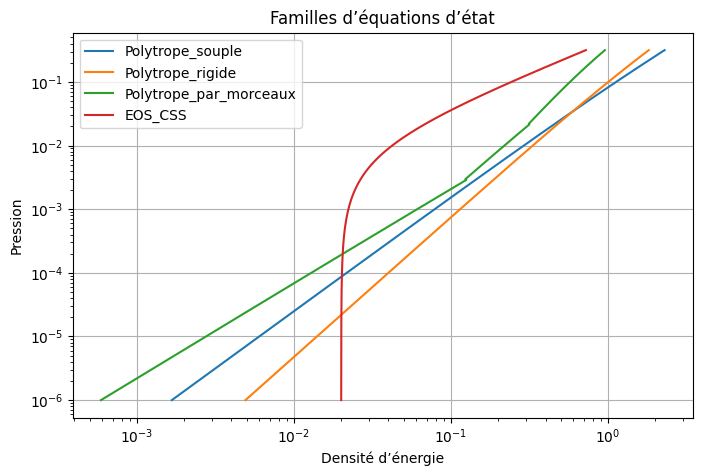

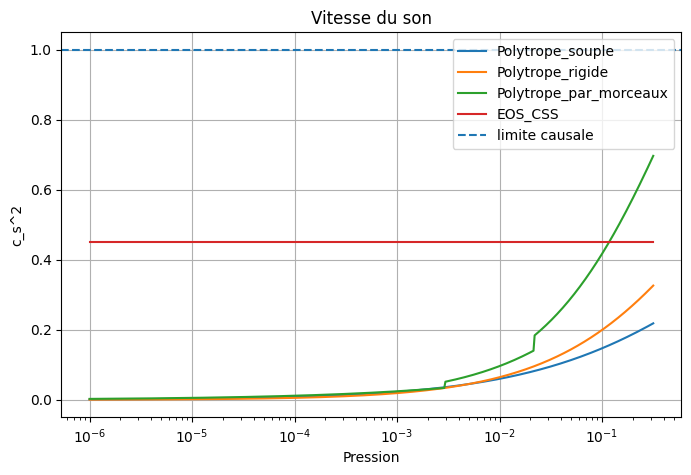

In [10]:

plt.figure(figsize=(8, 5))
for eos in eos_models:
    eps = eos.energy_from_pressure(pressure_grid)
    plt.loglog(eps, pressure_grid, label=eos.name)

plt.xlabel("Densité d’énergie")
plt.ylabel("Pression")
plt.title("Familles d’équations d’état")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for eos in eos_models:
    cs2 = eos.sound_speed_squared_from_pressure(pressure_grid)
    plt.semilogx(pressure_grid, cs2, label=eos.name)

plt.axhline(1.0, linestyle="--", label="limite causale")
plt.xlabel("Pression")
plt.ylabel("c_s^2")
plt.title("Vitesse du son")
plt.grid(True)
plt.legend()
plt.show()



# 8. Secteur directionnel et anisotropie

Nous conservons le modèle réduit de 0.2.25 :

\[
\rho_D
=
\frac12(fd'^2+\mu_D^2d^2),
\]

\[
p_r^D
=
\frac12(fd'^2-\mu_D^2d^2),
\]

\[
p_t^D
=
-\frac12(fd'^2+\mu_D^2d^2).
\]

L’anisotropie de matière produit :

\[
J_D=-\sqrt{\frac23}\Delta_m.
\]


In [11]:

def directional_stress(radius, mass, field, derivative, mu):
    f = max(1.0 - 2.0 * mass / radius, 1e-12)
    gradient = f * derivative**2

    rho_D = 0.5 * (gradient + mu**2 * field**2)
    p_r_D = 0.5 * (gradient - mu**2 * field**2)
    p_t_D = -0.5 * (gradient + mu**2 * field**2)

    return rho_D, p_r_D, p_t_D


In [12]:

def matter_anisotropy(
    radius,
    mass,
    energy_density,
    radial_pressure,
    total_radial_pressure,
    lambda_a,
):
    if radial_pressure <= 0.0:
        return 0.0

    return (
        lambda_a
        * radius**2
        * (energy_density + radial_pressure)
        * (
            mass
            + 4.0 * np.pi * radius**3 * total_radial_pressure
        )
        / (radius**3 + 1e-12)
    )



# 9. Solveur stellaire général

Le solveur accepte n’importe quelle EOS conforme à `EOSBase`.

Il intègre :

\[
m,\quad
\Phi,\quad
p,\quad
d,\quad
d',
\quad
N_B,
\]

où \(N_B\) est le nombre baryonique géométrique :

\[
N_B'
=
4\pi r^2
\frac{n_B}{\sqrt{1-2m/r}}.
\]


In [13]:

def integrate_star(
    eos,
    p_center,
    d_center=0.0,
    lambda_a=0.0,
    mu=0.5,
    kappa=0.0,
    rmax=None,
    n_eval=None,
    endpoint_only=False,
):
    if p_center <= 0:
        raise ValueError("La pression centrale doit être positive.")

    rmax = CFG.rmax if rmax is None else float(rmax)
    n_eval = CFG.n_eval if n_eval is None else int(n_eval)

    r0 = 1e-5
    epsilon_c = float(eos.energy_from_pressure(np.array([p_center]))[0])
    nB_c = float(eos.baryon_density_from_pressure(np.array([p_center]))[0])

    d2_center = mu**2 * d_center / 3.0
    d0 = d_center + 0.5 * d2_center * r0**2
    v0 = d2_center * r0

    rho_D0 = 0.5 * mu**2 * d_center**2
    m0 = 4.0 * np.pi * (epsilon_c + rho_D0) * r0**3 / 3.0
    NB0 = 4.0 * np.pi * nB_c * r0**3 / 3.0

    y0 = [m0, 0.0, p_center, d0, v0, NB0]

    def rhs(radius, state):
        mass, phi_value, pressure, field, derivative, baryon_number = state
        p_m = max(pressure, 0.0)

        if p_m > 0.0:
            epsilon_m = float(eos.energy_from_pressure(np.array([p_m]))[0])
            nB = float(eos.baryon_density_from_pressure(np.array([p_m]))[0])
        else:
            epsilon_m = 0.0
            nB = 0.0

        f = max(1.0 - 2.0 * mass / radius, 1e-12)

        rho_D, p_r_D, p_t_D = directional_stress(
            radius, mass, field, derivative, mu
        )
        p_r_total = p_m + p_r_D

        delta_m = matter_anisotropy(
            radius,
            mass,
            epsilon_m,
            p_m,
            p_r_total,
            lambda_a,
        )

        p_t_m = p_m + delta_m
        J_D = np.sqrt(2.0 / 3.0) * (p_m - p_t_m)
        rho_total = epsilon_m + rho_D

        dm = 4.0 * np.pi * radius**2 * rho_total
        denominator = max(radius * (radius - 2.0 * mass), 1e-12)

        dphi = (
            mass + 4.0 * np.pi * radius**3 * p_r_total
        ) / denominator

        if p_m > 0.0:
            dp = (
                -(epsilon_m + p_m) * dphi
                + 2.0 * delta_m / radius
                - kappa * J_D * derivative
            )
        else:
            dp = 0.0

        dLambda = (dm / radius - mass / radius**2) / f
        dd = derivative

        dv = (
            -(2.0 / radius + dphi - dLambda) * derivative
            + mu**2 * field / f
            - kappa * J_D / f
        )

        dNB = 4.0 * np.pi * radius**2 * nB / np.sqrt(f)
        return [dm, dphi, dp, dd, dv, dNB]

    t_eval = None if endpoint_only else np.linspace(r0, rmax, n_eval)

    return solve_ivp(
        rhs,
        (r0, rmax),
        y0,
        t_eval=t_eval,
        method="DOP853",
        rtol=CFG.rtol,
        atol=CFG.atol,
        max_step=CFG.max_step,
    )



# 10. Surface et condition asymptotique


In [14]:

def locate_surface(radius, pressure):
    positive = np.where(pressure > 0.0)[0]

    if positive.size == 0:
        return float(radius[0]), 0

    index = int(positive[-1])
    return float(radius[index]), index


_SHOOTING_RESIDUAL_CACHE = {}

def asymptotic_residual(
    d_center,
    eos,
    p_center,
    lambda_a,
    mu,
    kappa,
):
    key = (
        eos.name,
        round(float(p_center), 14),
        round(float(d_center), 12),
        float(lambda_a),
        float(mu),
        float(kappa),
        RUN_MODE,
    )

    if key in _SHOOTING_RESIDUAL_CACHE:
        return _SHOOTING_RESIDUAL_CACHE[key]

    # Endpoint only: avoids generating thousands of unused points during shooting.
    solution = integrate_star(
        eos=eos,
        p_center=p_center,
        d_center=float(d_center),
        lambda_a=lambda_a,
        mu=mu,
        kappa=kappa,
        endpoint_only=True,
    )

    radius = float(solution.t[-1])
    field = float(solution.y[3, -1])
    derivative = float(solution.y[4, -1])

    residual = derivative + (mu + 1.0 / radius) * field
    _SHOOTING_RESIDUAL_CACHE[key] = residual
    return residual


In [15]:

def shoot_center_field(
    eos,
    p_center,
    lambda_a,
    mu,
    kappa,
    initial_guess=0.0,
):
    if kappa == 0.0 or lambda_a == 0.0:
        return 0.0, True

    guess = float(initial_guess)
    half_width = CFG.shooting_local_half_width

    # 1) Local continuation bracket around previous solution.
    local_trials = np.array([
        guess - half_width,
        guess,
        guess + half_width,
    ])

    local_residuals = np.array([
        asymptotic_residual(
            value, eos, p_center, lambda_a, mu, kappa
        )
        for value in local_trials
    ])

    for i in range(len(local_trials) - 1):
        if local_residuals[i] == 0.0:
            return float(local_trials[i]), True

        if local_residuals[i] * local_residuals[i + 1] < 0.0:
            result = root_scalar(
                lambda value: asymptotic_residual(
                    value, eos, p_center, lambda_a, mu, kappa
                ),
                bracket=(local_trials[i], local_trials[i + 1]),
                method="brentq",
                xtol=1e-9,
            )
            return float(result.root), bool(result.converged)

    # 2) Global fallback, much smaller than the original 41 full integrations.
    trials = np.linspace(
        -0.4,
        0.4,
        CFG.shooting_global_trials,
    )

    residuals = np.array([
        asymptotic_residual(
            value, eos, p_center, lambda_a, mu, kappa
        )
        for value in trials
    ])

    for i in range(len(trials) - 1):
        if residuals[i] == 0.0:
            return float(trials[i]), True

        if residuals[i] * residuals[i + 1] < 0.0:
            result = root_scalar(
                lambda value: asymptotic_residual(
                    value, eos, p_center, lambda_a, mu, kappa
                ),
                bracket=(trials[i], trials[i + 1]),
                method="brentq",
                xtol=1e-9,
            )
            return float(result.root), bool(result.converged)

    best = int(np.argmin(np.abs(residuals)))
    return float(trials[best]), False



# 11. Résumé d’une étoile

L’énergie de liaison est définie ici par :

\[
E_{\rm bind}
=
M_B-M,
\]

avec \(M_B\) proportionnelle à l’intégrale baryonique.


In [16]:

def fit_exterior_charge(radius, field, R_surface, mu):
    mask = radius > max(1.3 * R_surface, R_surface + 0.5)

    if not np.any(mask):
        return np.nan, np.nan

    rr = radius[mask]
    dd = field[mask]
    basis = np.exp(-mu * rr) / rr

    denominator = np.dot(basis, basis)
    if denominator <= 0:
        return np.nan, np.nan

    charge = np.dot(basis, dd) / denominator
    fitted = charge * basis
    rmse = np.sqrt(np.mean((fitted - dd) ** 2))

    return float(charge), float(rmse)


def solve_star_summary(
    eos,
    p_center,
    model="GR",
    lambda_a=0.02,
    mu=0.5,
    kappa=0.2,
    d_center_guess=0.0,
):
    coupled = model == "GVH"

    if coupled:
        d_center, shooting_converged = shoot_center_field(
            eos,
            p_center,
            lambda_a,
            mu,
            kappa,
            initial_guess=d_center_guess,
        )
    else:
        d_center = 0.0
        shooting_converged = True
        kappa = 0.0

    solution = integrate_star(
        eos=eos,
        p_center=p_center,
        d_center=d_center,
        lambda_a=lambda_a,
        mu=mu,
        kappa=kappa,
        endpoint_only=False,
    )

    radius = solution.t
    mass = solution.y[0]
    pressure = solution.y[2]
    field = solution.y[3]
    baryon_number = solution.y[5]

    R_surface, index = locate_surface(radius, pressure)

    M_surface = float(mass[index])
    M_total = float(mass[-1])
    M_baryon = float(baryon_number[index])

    Q_D, Q_rmse = fit_exterior_charge(
        radius,
        field,
        R_surface,
        mu,
    )

    epsilon_center = float(
        eos.energy_from_pressure(np.array([p_center]))[0]
    )

    cs2_center = float(
        eos.sound_speed_squared_from_pressure(
            np.array([p_center])
        )[0]
    )

    return {
        "EOS": eos.name,
        "model": model,
        "p_center": float(p_center),
        "epsilon_center": epsilon_center,
        "R_star": R_surface,
        "M_star": M_surface,
        "M_total": M_total,
        "M_baryon": M_baryon,
        "binding_energy": M_baryon - M_total,
        "compactness": 2.0 * M_surface / R_surface,
        "Q_D": Q_D,
        "Q_fit_rmse": Q_rmse,
        "max_abs_d": float(np.max(np.abs(field))),
        "d_center": float(d_center),
        "cs2_center": cs2_center,
        "shooting_converged": bool(shooting_converged),
        "solver_success": bool(solution.success),
        "solver_message": str(solution.message),
        "run_mode": RUN_MODE,
    }



# 12. Construction optimisée des séquences

Le mode rapide utilise moins d’EOS et moins de pressions centrales.

Le mode production :

- utilise les quatre EOS ;
- reprend un checkpoint existant ;
- sauvegarde après chaque étoile ;
- réutilise le dernier \(d_c\) comme estimation initiale pour la pression suivante.


In [17]:

selected_eos = eos_models[:CFG.eos_count]
central_pressures = np.logspace(
    -4.0,
    -0.75,
    CFG.pressure_count,
)

required_jobs = [
    (eos.name, float(pressure), model)
    for eos in selected_eos
    for pressure in central_pressures
    for model in ["GR", "GVH"]
]

if CHECKPOINT_PATH.exists():
    checkpoint_df = pd.read_csv(CHECKPOINT_PATH)
    print(f"Checkpoint chargé : {len(checkpoint_df)} résultats.")
else:
    checkpoint_df = pd.DataFrame()

completed_keys = set()

if not checkpoint_df.empty:
    completed_keys = {
        (
            str(row["EOS"]),
            round(float(row["p_center"]), 14),
            str(row["model"]),
        )
        for _, row in checkpoint_df.iterrows()
    }

sequence_rows = (
    checkpoint_df.to_dict("records")
    if not checkpoint_df.empty
    else []
)

start_time = time.perf_counter()

for eos in selected_eos:
    previous_d_center = 0.0

    # Recover the last available warm start for this EOS.
    existing_eos_gvh = [
        row for row in sequence_rows
        if row.get("EOS") == eos.name and row.get("model") == "GVH"
    ]

    if existing_eos_gvh:
        existing_eos_gvh = sorted(
            existing_eos_gvh,
            key=lambda row: float(row["p_center"]),
        )
        previous_d_center = float(
            existing_eos_gvh[-1].get("d_center", 0.0)
        )

    for pressure in central_pressures:
        for model in ["GR", "GVH"]:
            key = (
                eos.name,
                round(float(pressure), 14),
                model,
            )

            if key in completed_keys:
                continue

            print(
                f"[{RUN_MODE}] EOS={eos.name} "
                f"p_c={pressure:.4e} modèle={model}"
            )

            summary = solve_star_summary(
                eos=eos,
                p_center=float(pressure),
                model=model,
                lambda_a=0.02,
                mu=0.5,
                kappa=0.2,
                d_center_guess=previous_d_center,
            )

            if model == "GVH":
                previous_d_center = float(summary["d_center"])

            sequence_rows.append(summary)
            completed_keys.add(key)

            if len(sequence_rows) % CFG.checkpoint_every == 0:
                pd.DataFrame(sequence_rows).to_csv(
                    CHECKPOINT_PATH,
                    index=False,
                )

sequence_df = pd.DataFrame(sequence_rows)

# Keep only the current selected configuration and remove duplicates.
sequence_df = sequence_df[
    sequence_df["EOS"].isin([eos.name for eos in selected_eos])
].copy()

sequence_df = (
    sequence_df
    .drop_duplicates(
        subset=["EOS", "p_center", "model"],
        keep="last",
    )
    .sort_values(["EOS", "model", "p_center"])
    .reset_index(drop=True)
)

sequence_df.to_csv(CHECKPOINT_PATH, index=False)

elapsed = time.perf_counter() - start_time

print("Séquences terminées :", len(sequence_df))
print(f"Temps de cette exécution : {elapsed:.1f} s")
sequence_df.head()


[FAST] EOS=Polytrope_souple p_c=1.0000e-04 modèle=GR
[FAST] EOS=Polytrope_souple p_c=1.0000e-04 modèle=GVH
[FAST] EOS=Polytrope_souple p_c=2.9126e-04 modèle=GR
[FAST] EOS=Polytrope_souple p_c=2.9126e-04 modèle=GVH
[FAST] EOS=Polytrope_souple p_c=8.4834e-04 modèle=GR
[FAST] EOS=Polytrope_souple p_c=8.4834e-04 modèle=GVH
[FAST] EOS=Polytrope_souple p_c=2.4709e-03 modèle=GR
[FAST] EOS=Polytrope_souple p_c=2.4709e-03 modèle=GVH
[FAST] EOS=Polytrope_souple p_c=7.1969e-03 modèle=GR
[FAST] EOS=Polytrope_souple p_c=7.1969e-03 modèle=GVH
[FAST] EOS=Polytrope_souple p_c=2.0962e-02 modèle=GR
[FAST] EOS=Polytrope_souple p_c=2.0962e-02 modèle=GVH
[FAST] EOS=Polytrope_souple p_c=6.1054e-02 modèle=GR
[FAST] EOS=Polytrope_souple p_c=6.1054e-02 modèle=GVH
[FAST] EOS=Polytrope_souple p_c=1.7783e-01 modèle=GR
[FAST] EOS=Polytrope_souple p_c=1.7783e-01 modèle=GVH
[FAST] EOS=Polytrope_rigide p_c=1.0000e-04 modèle=GR
[FAST] EOS=Polytrope_rigide p_c=1.0000e-04 modèle=GVH
[FAST] EOS=Polytrope_rigide p_c=2.912

,EOS,model,p_center,epsilon_center,R_star,M_star,M_total,M_baryon,binding_energy,compactness,Q_D,Q_fit_rmse,max_abs_d,d_center,cs2_center,shooting_converged,solver_success,solver_message,run_mode
0,Polytrope_rigide,GR,0.000100,0.039928,0.281277,0.001512,0.001527,0.001516,-0.000011,0.010750,0.0,0.0,0.0,0.0,0.005496,True,True,The solver successfully reached the end of the...,FAST
1,Polytrope_rigide,GR,0.000291,0.065018,0.293506,0.002797,0.002826,0.002810,-0.000015,0.019058,0.0,0.0,0.0,0.0,0.009811,True,True,The solver successfully reached the end of the...,FAST
2,Polytrope_rigide,GR,0.000848,0.106012,0.305735,0.005116,0.005163,0.005160,-0.000004,0.033464,0.0,0.0,0.0,0.0,0.017465,True,True,The solver successfully reached the end of the...,FAST
3,Polytrope_rigide,GR,0.002471,0.173253,0.317964,0.009178,0.009232,0.009317,0.000085,0.057731,0.0,0.0,0.0,0.0,0.030935,True,True,The solver successfully reached the end of the...,FAST
4,Polytrope_rigide,GR,0.007197,0.284307,0.330193,0.015906,0.015916,0.016320,0.000404,0.096342,0.0,0.0,0.0,0.0,0.054315,True,True,The solver successfully reached the end of the...,FAST



# 13. Nettoyage physique

Une solution est retenue si :

- le solveur réussit ;
- \(R>0\) ;
- \(M>0\) ;
- \(2M/R<1\) ;
- les valeurs sont finies.


In [18]:

sequence_df["finite"] = np.isfinite(
    sequence_df[
        [
            "R_star",
            "M_star",
            "M_total",
            "M_baryon",
            "compactness",
        ]
    ]
).all(axis=1)

sequence_df["physical_basic"] = (
    sequence_df["solver_success"]
    & sequence_df["finite"]
    & (sequence_df["R_star"] > 0.0)
    & (sequence_df["M_star"] > 0.0)
    & (sequence_df["compactness"] < 1.0)
)

physical_sequences = sequence_df[
    sequence_df["physical_basic"]
].copy()

physical_sequences.shape


(32, 21)


# 14. Critère de stabilité \(dM/d\epsilon_c\)

Le critère de retournement utilisé est :

\[
\frac{dM}{d\epsilon_c}>0
\quad\Rightarrow\quad
\text{branche stable candidate},
\]

\[
\frac{dM}{d\epsilon_c}<0
\quad\Rightarrow\quad
\text{branche instable candidate}.
\]

Il s’agit d’un critère nécessaire usuel le long d’une séquence à paramètres fixés, mais pas d’un calcul complet des modes radiaux.


In [19]:

def add_turning_point_stability(dataframe):
    required = {"EOS", "model", "epsilon_center", "M_star"}
    missing = required.difference(dataframe.columns)

    if missing:
        raise ValueError(
            f"Colonnes manquantes pour la stabilité : {sorted(missing)}"
        )

    if dataframe.empty:
        return dataframe.copy()

    frames = []

    for (eos_name, model), group in dataframe.groupby(["EOS", "model"]):
        group = group.sort_values("epsilon_center").copy()

        epsilon = group["epsilon_center"].to_numpy(dtype=float)
        mass = group["M_star"].to_numpy(dtype=float)

        if len(group) >= 3 and np.all(np.diff(epsilon) > 0):
            derivative = np.gradient(mass, epsilon)
        else:
            derivative = np.full_like(mass, np.nan)

        group["dM_dEcentral"] = derivative
        group["stable_turning_point"] = derivative > 0.0

        if np.isfinite(mass).any():
            max_index = int(np.nanargmax(mass))
            group["stable_before_mass_max"] = (
                np.arange(len(group)) <= max_index
            )
        else:
            group["stable_before_mass_max"] = False

        frames.append(group)

    return pd.concat(frames, ignore_index=True)


stability_df = add_turning_point_stability(
    physical_sequences
)

stability_df.head()


,EOS,model,p_center,epsilon_center,R_star,M_star,M_total,M_baryon,binding_energy,compactness,...,cs2_center,shooting_converged,solver_success,solver_message,run_mode,finite,physical_basic,dM_dEcentral,stable_turning_point,stable_before_mass_max
0,Polytrope_rigide,GR,0.000100,0.039928,0.281277,0.001512,0.001527,0.001516,-0.000011,0.010750,...,0.005496,True,True,The solver successfully reached the end of the...,FAST,True,True,0.051212,True,True
1,Polytrope_rigide,GR,0.000291,0.065018,0.293506,0.002797,0.002826,0.002810,-0.000015,0.019058,...,0.009811,True,True,The solver successfully reached the end of the...,FAST,True,True,0.053244,True,True
2,Polytrope_rigide,GR,0.000848,0.106012,0.305735,0.005116,0.005163,0.005160,-0.000004,0.033464,...,0.017465,True,True,The solver successfully reached the end of the...,FAST,True,True,0.058025,True,True
3,Polytrope_rigide,GR,0.002471,0.173253,0.317964,0.009178,0.009232,0.009317,0.000085,0.057731,...,0.030935,True,True,The solver successfully reached the end of the...,FAST,True,True,0.060480,True,True
4,Polytrope_rigide,GR,0.007197,0.284307,0.330193,0.015906,0.015916,0.016320,0.000404,0.096342,...,0.054315,True,True,The solver successfully reached the end of the...,FAST,True,True,0.057994,True,True



# 15. Causalité sur chaque étoile

Pour chaque état central, nous vérifions :

\[
0\le c_s^2(p_c)\le1.
\]

Une version ultérieure devra vérifier le profil complet \(c_s^2(r)\).


In [20]:

if "cs2_center" not in stability_df.columns:
    stability_df["cs2_center"] = np.nan

stability_df["causal_center"] = (
    (stability_df["cs2_center"] >= -1e-8)
    & (stability_df["cs2_center"] <= 1.0 + 1e-8)
)

if "stable_before_mass_max" not in stability_df.columns:
    stability_df["stable_before_mass_max"] = False

if "binding_energy" not in stability_df.columns:
    stability_df["binding_energy"] = np.nan

stability_df["stable_candidate"] = (
    stability_df["stable_before_mass_max"]
    & stability_df["causal_center"]
    & (stability_df["binding_energy"] > 0.0)
)

stability_df[
    [
        "EOS",
        "model",
        "epsilon_center",
        "M_star",
        "R_star",
        "stable_candidate",
    ]
].head()


,EOS,model,epsilon_center,M_star,R_star,stable_candidate
0,Polytrope_rigide,GR,0.039928,0.001512,0.281277,False
1,Polytrope_rigide,GR,0.065018,0.002797,0.293506,False
2,Polytrope_rigide,GR,0.106012,0.005116,0.305735,False
3,Polytrope_rigide,GR,0.173253,0.009178,0.317964,True
4,Polytrope_rigide,GR,0.284307,0.015906,0.330193,True



# 16. Résultats maximaux par EOS


In [21]:

maximum_rows = []

for (eos_name, model), group in stability_df.groupby(["EOS", "model"]):
    index = group["M_star"].idxmax()
    row = group.loc[index]

    maximum_rows.append({
        "EOS": eos_name,
        "model": model,
        "M_max": row["M_star"],
        "R_at_Mmax": row["R_star"],
        "epsilon_center_at_Mmax": row["epsilon_center"],
        "compactness_at_Mmax": row["compactness"],
        "binding_at_Mmax": row["binding_energy"],
        "Q_D_at_Mmax": row["Q_D"],
        "causal_center": row["causal_center"],
    })

maximum_mass_df = pd.DataFrame(maximum_rows)
maximum_mass_df


,EOS,model,M_max,R_at_Mmax,epsilon_center_at_Mmax,compactness_at_Mmax,binding_at_Mmax,Q_D_at_Mmax,causal_center
0,Polytrope_rigide,GR,0.050896,0.293506,1.343952,0.346812,0.004575,0.000000,True
1,Polytrope_rigide,GVH,0.050896,0.293506,1.343952,0.346812,0.004575,-0.000002,True
2,Polytrope_souple,GR,0.047284,0.330193,1.599142,0.286404,0.002988,0.000000,True
3,Polytrope_souple,GVH,0.047284,0.330193,1.599142,0.286404,0.002989,-0.000002,True



# 17. Courbes masse–rayon


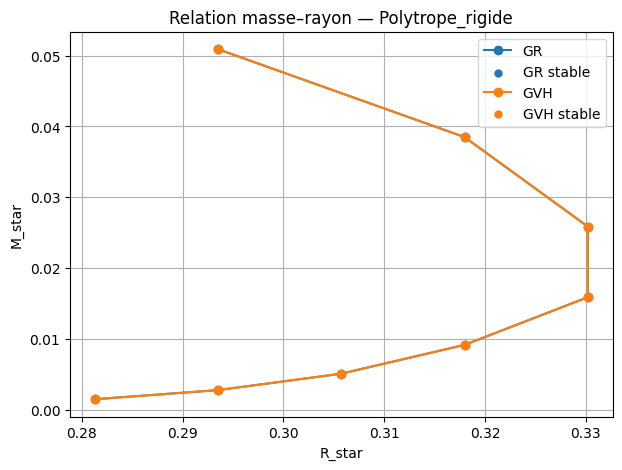

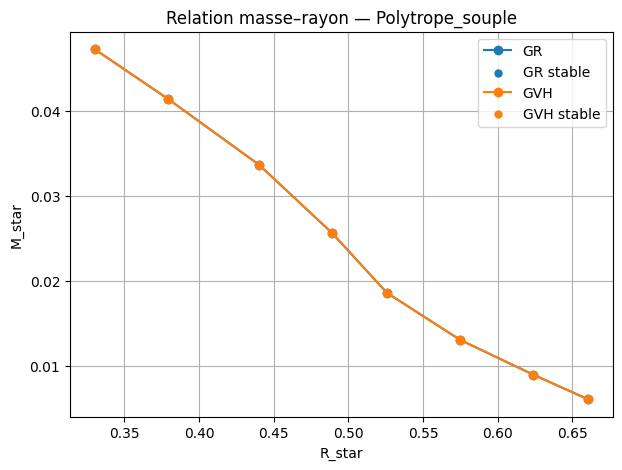

In [22]:

for eos_name in stability_df["EOS"].unique():
    subset = stability_df[
        stability_df["EOS"] == eos_name
    ]

    plt.figure(figsize=(7, 5))

    for model, group in subset.groupby("model"):
        group = group.sort_values("epsilon_center")

        plt.plot(
            group["R_star"],
            group["M_star"],
            marker="o",
            label=model,
        )

        stable = group[group["stable_candidate"]]

        plt.scatter(
            stable["R_star"],
            stable["M_star"],
            s=25,
            label=f"{model} stable",
        )

    plt.xlabel("R_star")
    plt.ylabel("M_star")
    plt.title(f"Relation masse–rayon — {eos_name}")
    plt.grid(True)
    plt.legend()
    plt.show()



# 18. Masse en fonction de la densité centrale


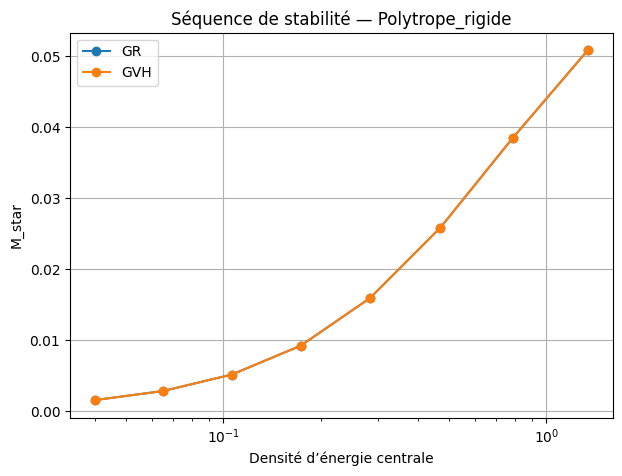

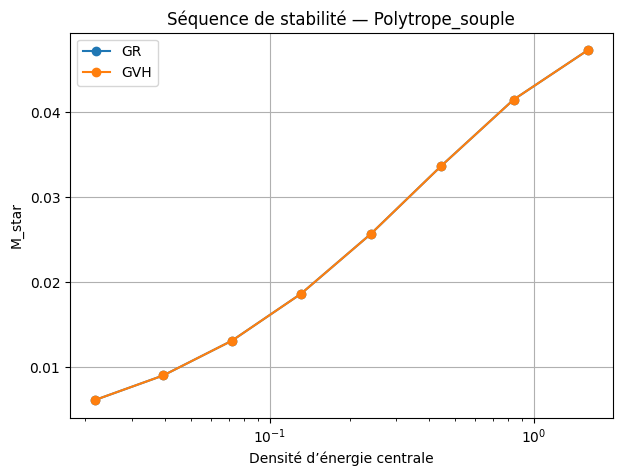

In [23]:

for eos_name in stability_df["EOS"].unique():
    subset = stability_df[
        stability_df["EOS"] == eos_name
    ]

    plt.figure(figsize=(7, 5))

    for model, group in subset.groupby("model"):
        group = group.sort_values("epsilon_center")

        plt.semilogx(
            group["epsilon_center"],
            group["M_star"],
            marker="o",
            label=model,
        )

    plt.xlabel("Densité d’énergie centrale")
    plt.ylabel("M_star")
    plt.title(f"Séquence de stabilité — {eos_name}")
    plt.grid(True)
    plt.legend()
    plt.show()



# 19. Énergie de liaison


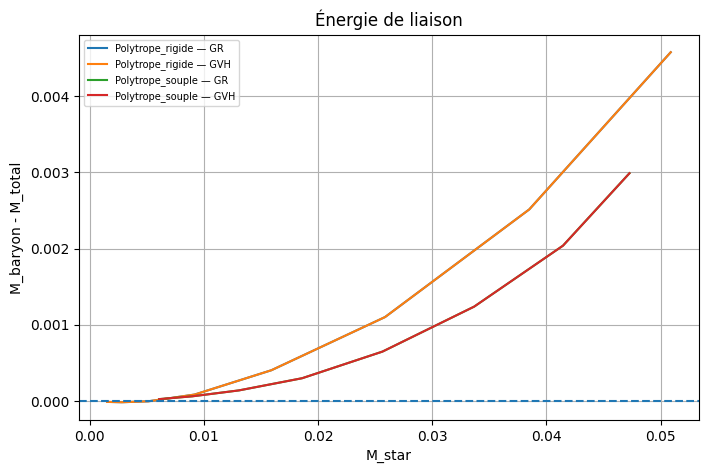

In [24]:

plt.figure(figsize=(8, 5))

for (eos_name, model), group in stability_df.groupby(["EOS", "model"]):
    group = group.sort_values("M_star")

    plt.plot(
        group["M_star"],
        group["binding_energy"],
        label=f"{eos_name} — {model}",
    )

plt.axhline(0.0, linestyle="--")
plt.xlabel("M_star")
plt.ylabel("M_baryon - M_total")
plt.title("Énergie de liaison")
plt.grid(True)
plt.legend(fontsize=7)
plt.show()



# 20. Effet directionnel sur la masse maximale

Nous calculons :

\[
\Delta M_{\max}
=
M_{\max}^{\rm GVH}
-
M_{\max}^{\rm GR},
\]

et le changement relatif correspondant.


In [25]:

max_pivot = maximum_mass_df.pivot(
    index="EOS",
    columns="model",
    values="M_max",
)

max_comparison = pd.DataFrame({
    "EOS": max_pivot.index,
    "Mmax_GR": max_pivot.get("GR"),
    "Mmax_GVH": max_pivot.get("GVH"),
}).reset_index(drop=True)

max_comparison["Delta_Mmax"] = (
    max_comparison["Mmax_GVH"]
    - max_comparison["Mmax_GR"]
)

max_comparison["Relative_Delta_Mmax"] = (
    max_comparison["Delta_Mmax"]
    / max_comparison["Mmax_GR"]
)

max_comparison


,EOS,Mmax_GR,Mmax_GVH,Delta_Mmax,Relative_Delta_Mmax
0,Polytrope_rigide,0.050896,0.050896,3.374874e-09,6.630954e-08
1,Polytrope_souple,0.047284,0.047284,1.301978e-09,2.753506e-08



# 21. Charge directionnelle le long des séquences


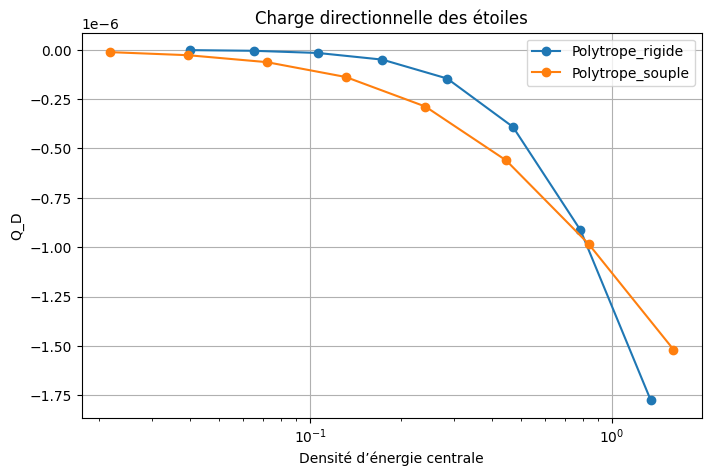

In [26]:

plt.figure(figsize=(8, 5))

gvh_rows = stability_df[
    stability_df["model"] == "GVH"
]

for eos_name, group in gvh_rows.groupby("EOS"):
    group = group.sort_values("epsilon_center")

    plt.semilogx(
        group["epsilon_center"],
        group["Q_D"],
        marker="o",
        label=eos_name,
    )

plt.xlabel("Densité d’énergie centrale")
plt.ylabel("Q_D")
plt.title("Charge directionnelle des étoiles")
plt.grid(True)
plt.legend()
plt.show()



# 22. Carte de classification

Chaque solution reçoit un statut :

- `STABLE-CANDIDATE`
- `UNSTABLE-TURNING-POINT`
- `NONCAUSAL-CENTER`
- `UNBOUND`
- `NUMERICAL-CHECK`


In [27]:

def classify_sequence_row(row):
    if not bool(row.get("physical_basic", False)):
        return "NUMERICAL-CHECK"
    if not bool(row.get("causal_center", False)):
        return "NONCAUSAL-CENTER"
    if not np.isfinite(row.get("binding_energy", np.nan)):
        return "NUMERICAL-CHECK"
    if row["binding_energy"] <= 0.0:
        return "UNBOUND"
    if not bool(row.get("stable_before_mass_max", False)):
        return "UNSTABLE-TURNING-POINT"
    return "STABLE-CANDIDATE"


stability_df["classification"] = stability_df.apply(
    classify_sequence_row,
    axis=1,
)

stability_df["classification"].value_counts()


,count
classification,
STABLE-CANDIDATE,26
UNBOUND,6



# 23. Exemple de table EOS synthétique

Cette cellule crée une table au format attendu. Elle sert uniquement à tester l’interface `TabulatedEOS`.


In [28]:

synthetic_energy = np.logspace(-3, 0.2, 300)
synthetic_pressure = 0.25 * synthetic_energy**1.7
synthetic_baryon = np.maximum(
    synthetic_energy - synthetic_pressure,
    1e-12,
)

synthetic_table = pd.DataFrame({
    "energy_density": synthetic_energy,
    "pressure": synthetic_pressure,
    "baryon_density": synthetic_baryon,
})

synthetic_table.to_csv(
    "GVH_Diagonal_Cubic_0.2.26_EOS_Table_Template.csv",
    index=False,
)

tabulated_test_eos = TabulatedEOS(
    synthetic_energy,
    synthetic_pressure,
    synthetic_baryon,
    name="Synthetic_Tabulated_Test",
)

print(
    tabulated_test_eos.sound_speed_squared_from_pressure(
        np.array([synthetic_pressure[100]])
    )
)


[0.018947069212]



# 24. Distinction entre prototype et données réelles

Le notebook est prêt à recevoir une table physique, mais il faudra vérifier :

1. les unités ;
2. la monotonie ;
3. la continuité thermodynamique ;
4. la présence ou l’absence de transitions de phase ;
5. la causalité ;
6. la plage de densité ;
7. la provenance et la licence des données.

Aucune EOS analytique de ce notebook ne doit être présentée comme une table nucléaire observationnellement validée.


In [29]:

eos_status_table = pd.DataFrame([
    {
        "EOS": eos.name,
        "type": type(eos).__name__,
        "status": "ANALYTIC PROTOTYPE",
    }
    for eos in eos_models
])

eos_status_table = pd.concat([
    eos_status_table,
    pd.DataFrame([
        {
            "EOS": "Synthetic_Tabulated_Test",
            "type": "TabulatedEOS",
            "status": "INTERFACE TEST ONLY",
        }
    ]),
], ignore_index=True)

eos_status_table


,EOS,type,status
0,Polytrope_souple,RelativisticPolytrope,ANALYTIC PROTOTYPE
1,Polytrope_rigide,RelativisticPolytrope,ANALYTIC PROTOTYPE
2,Polytrope_par_morceaux,PiecewisePolytrope,ANALYTIC PROTOTYPE
3,EOS_CSS,ConstantSoundSpeedEOS,ANALYTIC PROTOTYPE
4,Synthetic_Tabulated_Test,TabulatedEOS,INTERFACE TEST ONLY



# 25. Validation automatique


In [30]:

eos_interface_ok = all(
    all(
        hasattr(eos, method)
        for method in [
            "energy_from_pressure",
            "pressure_from_energy",
            "baryon_density_from_pressure",
            "sound_speed_squared_from_pressure",
        ]
    )
    for eos in eos_models
)

eos_finite_ok = bool(
    np.isfinite(
        eos_audit[
            [
                "min_energy",
                "max_energy",
                "min_cs2",
                "max_cs2",
            ]
        ].to_numpy()
    ).all()
)

sequence_nonempty_ok = len(stability_df) > 0

physical_sequence_ok = bool(
    stability_df["physical_basic"].any()
)

turning_point_ok = bool(
    maximum_mass_df["M_max"].notna().all()
)

gr_field_limit_ok = bool(
    np.nanmax(
        stability_df.loc[
            stability_df["model"] == "GR",
            "max_abs_d",
        ]
    ) < 1e-10
)

binding_computed_ok = bool(
    np.isfinite(stability_df["binding_energy"]).all()
)

classification_ok = bool(
    stability_df["classification"].notna().all()
)

table_interface_ok = bool(
    np.isfinite(
        tabulated_test_eos.energy_from_pressure(
            np.array([synthetic_pressure[100]])
        )
    ).all()
)

validation_df = pd.DataFrame([
    {
        "test": "EOS common interface",
        "status": "PASS" if eos_interface_ok else "FAIL",
    },
    {
        "test": "finite EOS audit",
        "status": "PASS" if eos_finite_ok else "FAIL",
    },
    {
        "test": "nonempty stellar sequences",
        "status": "PASS" if sequence_nonempty_ok else "FAIL",
    },
    {
        "test": "physical stellar solutions",
        "status": "PASS" if physical_sequence_ok else "CHECK",
    },
    {
        "test": "maximum-mass turning points",
        "status": "PASS" if turning_point_ok else "CHECK",
    },
    {
        "test": "GR directional-field limit",
        "status": "PASS" if gr_field_limit_ok else "FAIL",
    },
    {
        "test": "binding energy computed",
        "status": "PASS" if binding_computed_ok else "FAIL",
    },
    {
        "test": "sequence classification",
        "status": "PASS" if classification_ok else "FAIL",
    },
    {
        "test": "tabulated EOS interface",
        "status": "PASS" if table_interface_ok else "FAIL",
    },
])

validation_df


,test,status
0,EOS common interface,PASS
1,finite EOS audit,PASS
2,nonempty stellar sequences,PASS
3,physical stellar solutions,PASS
4,maximum-mass turning points,PASS
5,GR directional-field limit,PASS
6,binding energy computed,PASS
7,sequence classification,PASS
8,tabulated EOS interface,PASS


In [31]:

overall_status = (
    "PASS-STELLAR-SEQUENCE-FRAMEWORK"
    if bool((validation_df["status"] == "PASS").all())
    else "CHECK"
)

print("STATUT DU NOTEBOOK :", overall_status)
print("EOS RÉELLES PUBLIÉES INSÉRÉES : NON")
print("STABILITÉ RADIALE MODALE COMPLÈTE : NON ENCORE")


STATUT DU NOTEBOOK : PASS-STELLAR-SEQUENCE-FRAMEWORK
EOS RÉELLES PUBLIÉES INSÉRÉES : NON
STABILITÉ RADIALE MODALE COMPLÈTE : NON ENCORE



# 26. Export


In [32]:

import json

validation_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.26.1_Validation.csv",
    index=False,
)

eos_audit.to_csv(
    "GVH_Diagonal_Cubic_0.2.26.1_EOS_Audit.csv",
    index=False,
)

eos_status_table.to_csv(
    "GVH_Diagonal_Cubic_0.2.26.1_EOS_Status.csv",
    index=False,
)

sequence_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.26.1_All_Sequences.csv",
    index=False,
)

stability_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.26.1_Stability_Sequences.csv",
    index=False,
)

maximum_mass_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.26.1_Maximum_Masses.csv",
    index=False,
)

max_comparison.to_csv(
    "GVH_Diagonal_Cubic_0.2.26.1_GR_GVH_Maximum_Mass_Comparison.csv",
    index=False,
)

metadata = {
    "notebook_status": overall_status,
    "run_mode": RUN_MODE,
    "optimization": "endpoint-only shooting, warm starts, cache, checkpoint/resume",
    "EOS_models": [eos.name for eos in eos_models],
    "EOS_status": "analytic prototypes plus tabulated-data interface",
    "stability_criterion": "turning point dM/d epsilon_center",
    "causality_criterion": "0 <= c_s^2 <= 1 at center",
    "binding_energy": "M_baryon - M_total",
    "models_compared": ["GR", "GVH radial reduced model"],
    "real_published_EOS_loaded": False,
    "full_radial_mode_eigenproblem": False,
    "next_requirement": (
        "Load verified nuclear EOS tables and solve radial perturbation eigenfrequencies."
    ),
}

with open(
    "GVH_Diagonal_Cubic_0.2.26.1_Metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(metadata, file, indent=2, ensure_ascii=False)

print("Exports terminés.")


Exports terminés.



# 27. Conclusion scientifique

Ce notebook construit une infrastructure complète de séquences stellaires :

\[
\boxed{
\text{EOS}
\longrightarrow
\text{solutions TOV}
\longrightarrow
M(R)
\longrightarrow
\text{stabilité candidate}
}
\]

pour la limite GR et le modèle GVH radial réduit.

Le critère de retournement est :

\[
\boxed{
\frac{dM}{d\epsilon_c}>0
}
\]

sur la branche stable candidate.

La causalité locale exige :

\[
\boxed{
0\le c_s^2\le1
}.
\]

L’énergie de liaison utilisée est :

\[
\boxed{
E_{\rm bind}=M_B-M
}.
\]

Le notebook calcule :

- les séquences masse–rayon ;
- les masses maximales ;
- les branches stables et instables ;
- la causalité centrale ;
- l’énergie de liaison ;
- la charge directionnelle ;
- la variation de \(M_{\max}\) entre GR et GVH.

La conclusion correcte est :

\[
\boxed{
\text{cadre de stabilité stellaire construit et fonctionnel}
}
\]

mais :

\[
\boxed{
\text{aucune validation observationnelle finale sans EOS nucléaires vérifiées}
}.
\]

Le critère \(dM/d\epsilon_c\) ne remplace pas encore le calcul complet des fréquences propres radiales.

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.27\_Radial\_Oscillation\_Eigenmodes\_Stability.ipynb}
}
\]

Elle devra :

- dériver les équations de perturbations radiales ;
- résoudre le problème aux valeurs propres ;
- calculer \(\omega_0^2,\omega_1^2,\dots\) ;
- vérifier que \(\omega_0^2=0\) au point de masse maximale ;
- comparer la stabilité modale au critère de retournement ;
- inclure les perturbations du champ directionnel.


## Gain de la version optimisée

Le nombre d’intégrations coûteuses pendant le tir est réduit par :

\[
\text{continuation}
+
\text{recherche locale}
+
\text{cache}
+
\text{intégration au seul point final}.
\]

Le checkpoint permet de reprendre le calcul sans perdre les étoiles déjà terminées.
